In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

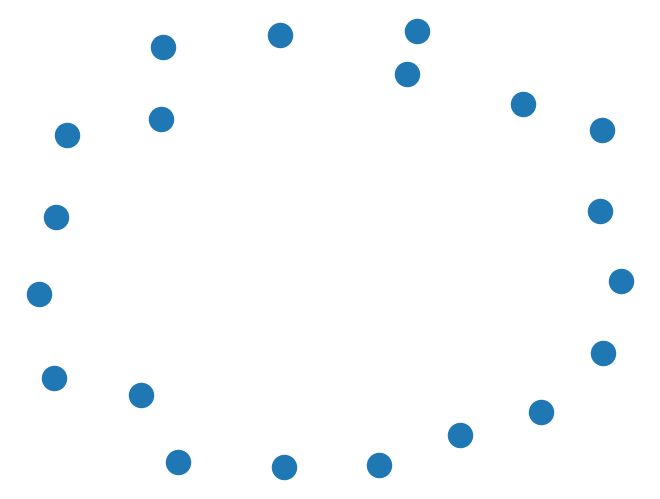

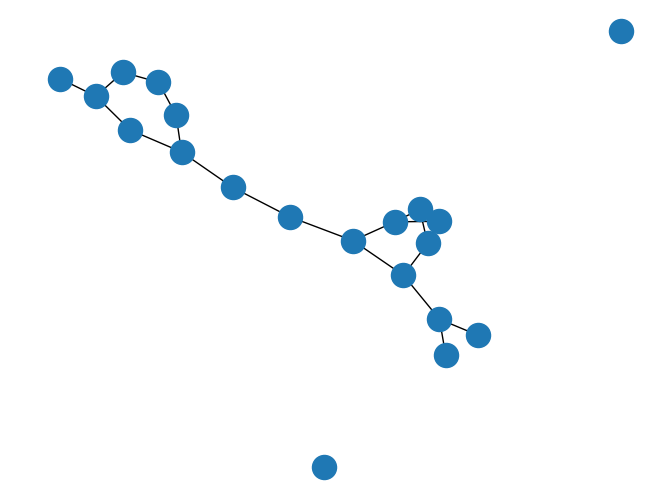

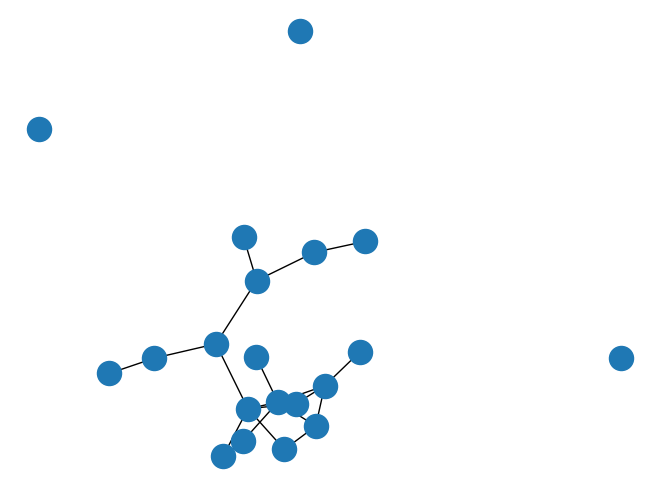

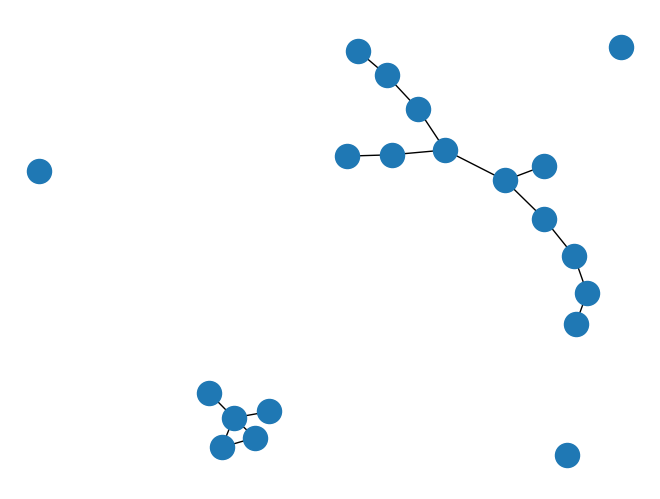

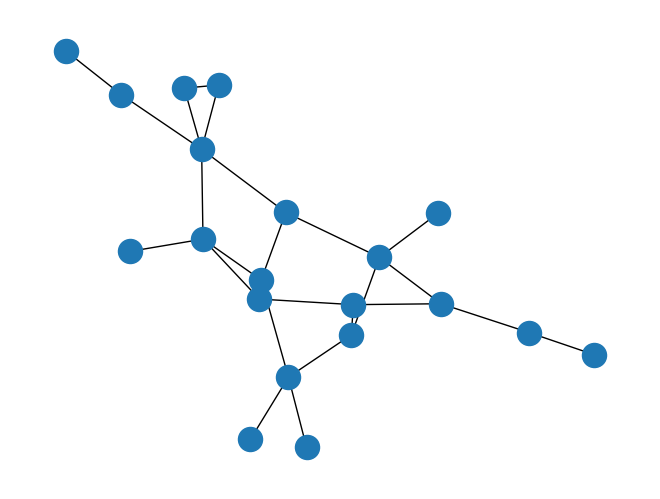

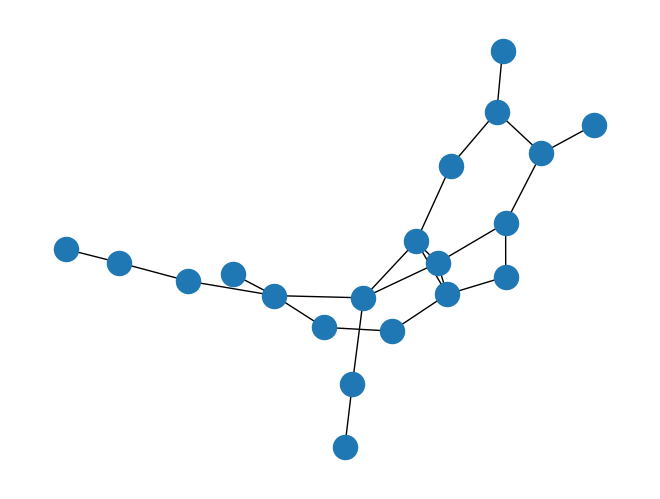

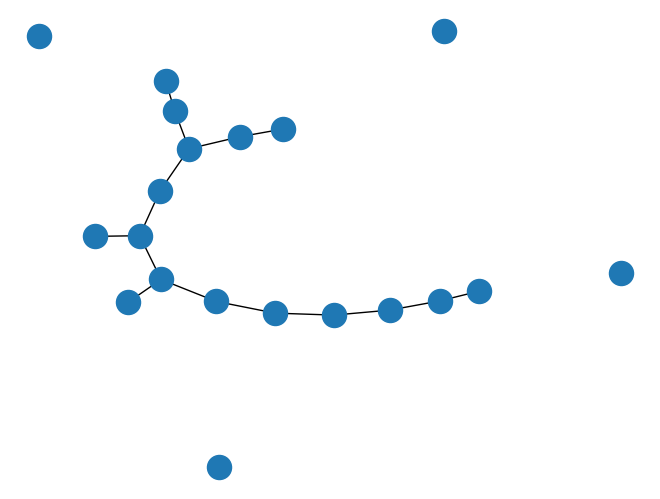

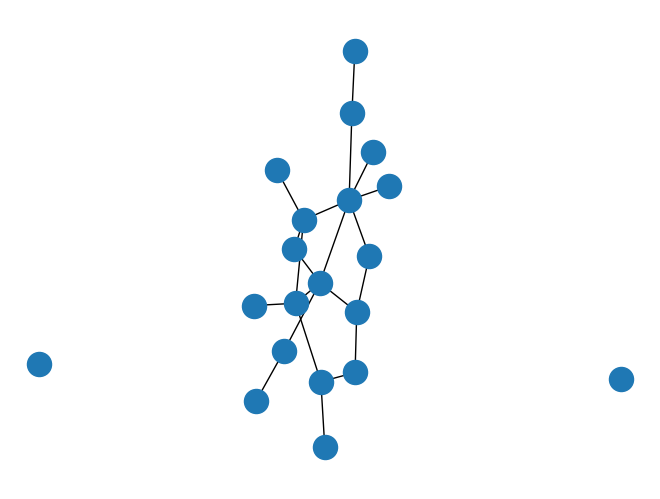

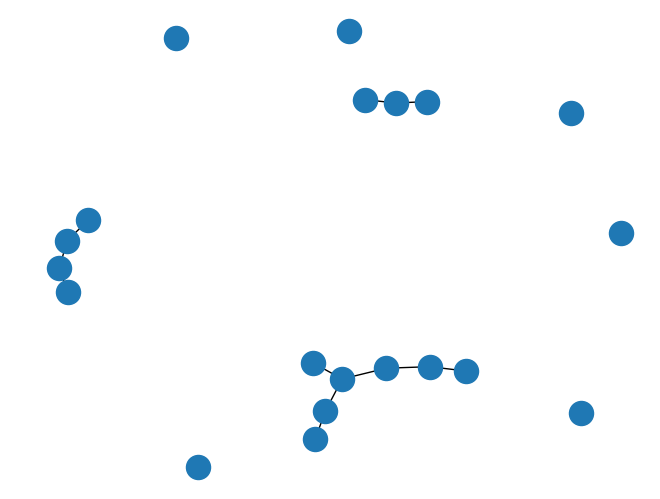

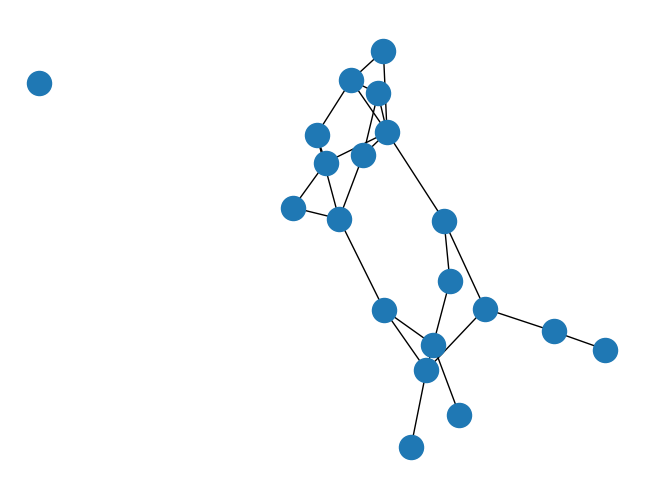

In [5]:
n = 20
its = 1000000
G = nx.empty_graph(n)
m = 0
t = 0
a = 2.2
b = 0.001
for step in range(its):
    if step %100000 == 0:
        nx.draw(G)
        plt.show()
    i, j = np.random.randint(0, n, 2)
    if i == j:
        continue
    if G.has_edge(i, j):
        delta_t = -len(list(nx.common_neighbors(G, i, j)))
        delta_m = -1
        G.remove_edge(i, j)
    else:
        delta_t = len(list(nx.common_neighbors(G, i, j)))
        delta_m = +1
        G.add_edge(i, j)

    dH = a * delta_m - b * delta_t
    if np.log(np.random.uniform()) < -dH:
        m += delta_m
        t += delta_t
    else:
        # revert
        if delta_m == 1:
            G.remove_edge(i, j)
        else:
            G.add_edge(i, j)

In [ ]:
n = 500
a=2.2
G = nx.empty_graph(n)
m=0
t = 0
its = 100000
burn_in = 20000

up_edges = []
up_tris = []
down_edges = []
down_tris = []

#upsweep
b_vals = np.linspace(0, 0.1, 100)
for b in b_vals:
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        if i == j:
            continue
        if G.has_edge(i, j):
            delta_t = -len(list(nx.common_neighbors(G, i, j)))
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(list(nx.common_neighbors(G, i, j)))
            delta_m = 1
            G.add_edge(i, j)
        
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    up_edges.append(total_edges / (its-burn_in))
    up_tris.append(total_tris / (its-burn_in))

#downsweep
for b in reversed(b_vals):
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        if i == j:
            continue
        if G.has_edge(i, j):
            delta_t = -len(list(nx.common_neighbors(G, i, j)))
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(list(nx.common_neighbors(G, i, j)))
            delta_m = 1
            G.add_edge(i, j)
        
        #dh is H(G) - H(G')
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    down_edges.append(total_edges / (its-burn_in))
    down_tris.append(total_tris / (its-burn_in))


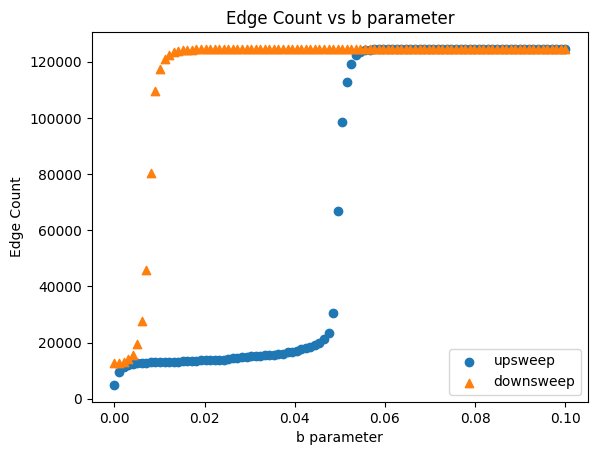

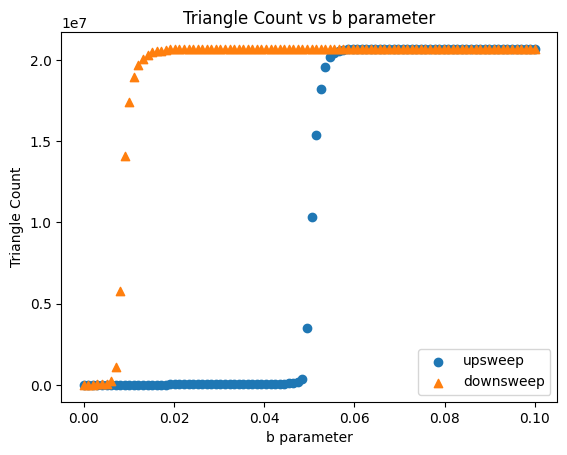

In [4]:
plt.figure()
plt.scatter(b_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'downsweep', marker = '^')
#title legend
plt.title('Edge Count vs b parameter')
plt.xlabel('b parameter')
plt.ylabel('Edge Count')
plt.legend()

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')
#title legend
plt.title('Triangle Count vs b parameter')
plt.xlabel('b parameter')
plt.ylabel('Triangle Count')
plt.legend()
plt.show()

In [ ]:
newGraph

complement

energy

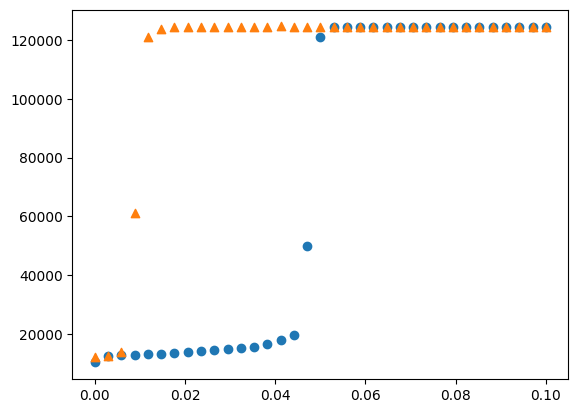

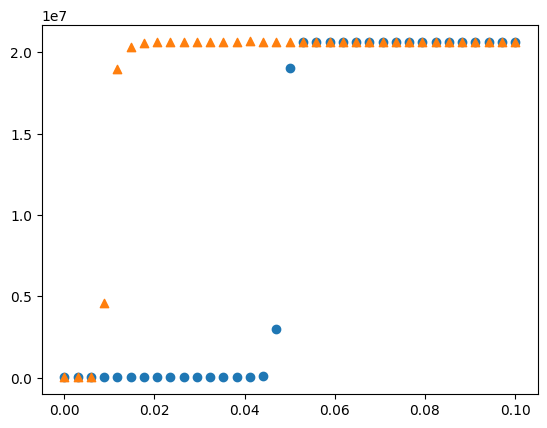

In [ ]:
n = 500
a=2.2
G = nx.empty_graph(n)
m=0
t = 0
its = 500000
burn_in = 50000
up_edges = []
up_tris = []
down_edges = []
down_tris = []

#upsweep
b_vals = np.linspace(0, 0.1, 35)
for b in b_vals:
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -len(list(nx.common_neighbors(G, i, j))) #G.neighbors(i).intersection(G.neighbors(j))
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(list(nx.common_neighbors(G, i, j))) #.size?
            delta_m = 1
            G.add_edge(i, j)
        
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    up_edges.append(total_edges / (its-burn_in))
    up_tris.append(total_tris / (its-burn_in))

#downsweep
for b in reversed(b_vals):
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        if i == j:
            continue
        if G.has_edge(i, j):
            delta_t = -len(list(nx.common_neighbors(G, i, j)))
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(list(nx.common_neighbors(G, i, j)))
            delta_m = 1
            G.add_edge(i, j)
        
        #dh is H(G) - H(G')
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    down_edges.append(total_edges / (its-burn_in))
    down_tris.append(total_tris / (its-burn_in))

plt.figure()
plt.scatter(b_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'downsweep', marker = '^')

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')

plt.show()


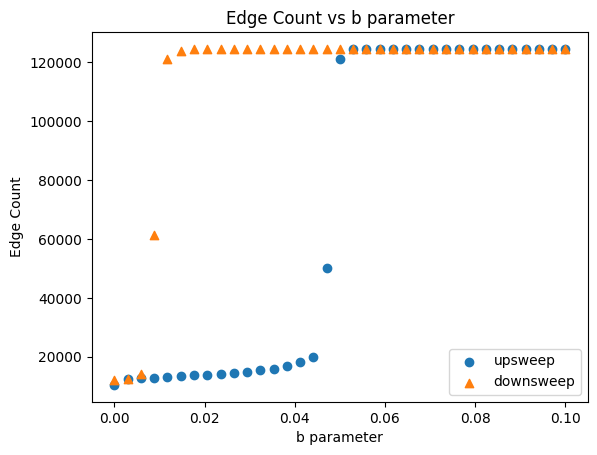

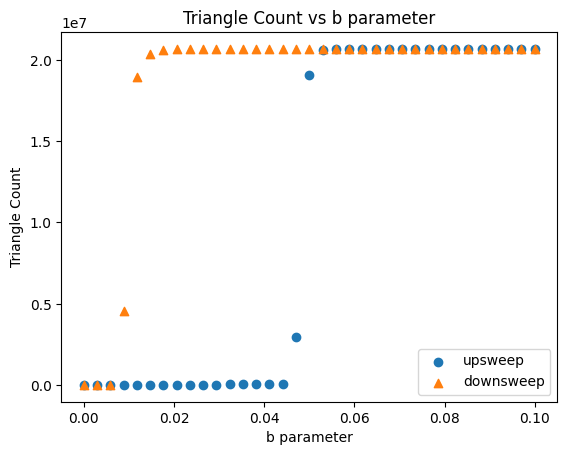

In [6]:
plt.figure()
plt.scatter(b_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'downsweep', marker = '^')
#title legend
plt.title('Edge Count vs b parameter')
plt.xlabel('b parameter')
plt.ylabel('Edge Count')
plt.legend()

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')
#title legend
plt.title('Triangle Count vs b parameter')
plt.xlabel('b parameter')
plt.ylabel('Triangle Count')
plt.legend()
plt.show()

In [7]:
import time
n = 500
a=2.2
G = nx.empty_graph(n)
m=0
t = 0
its = 500000
burn_in = 50000
up_edges = []
up_tris = []
down_edges = []
down_tris = []

#upsweep
b_vals = np.linspace(0, 0.1, 35)
for b in b_vals:
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -len(nx.common_neighbors(G, i, j)) # does G._adj[i].keys() & G._adj[j].keys()
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(nx.common_neighbors(G, i, j))
            delta_m = 1
            G.add_edge(i, j)
        
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, time = {elapsed:.2f} s")

    up_edges.append(total_edges / (its-burn_in))
    up_tris.append(total_tris / (its-burn_in))

#downsweep
for b in reversed(b_vals):
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -len(nx.common_neighbors(G, i, j))
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = len(nx.common_neighbors(G, i, j))
            delta_m = 1
            G.add_edge(i, j)
        
        #dh is H(G) - H(G')
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, time = {elapsed:.2f} s")

    down_edges.append(total_edges / (its-burn_in))
    down_tris.append(total_tris / (its-burn_in))

plt.figure()
plt.scatter(b_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'downsweep', marker = '^')

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')

plt.show()


b = 0.0000, time = 9.30 s


KeyboardInterrupt: 

In [6]:
class graphWithComplement:

    def __init__(self, n, empty=True):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        self.graph = nx.empty_graph(n) if empty else nx.complete_graph(n)
        self.complement = nx.complete_graph(n) if empty else nx.empty_graph(n)
        
    def add_edge(self, u, v):
        self.graph.add_edge(u, v)
        self.complement.remove_edge(u, v)
    
    def remove_edge(self, u, v):
        self.graph.remove_edge(u, v)
        self.complement.add_edge(u, v)
    
    def has_edge(self, u, v):
        return self.graph.has_edge(u, v)
    
    def number_of_common_neighbors(self, u, v, m=None):
        if m is None or m<self.half_of_all_edges:
            return len(nx.common_neighbors(self.graph, u, v))
        else:
            return self.n - 2 - len((self.complement.adj[u].keys() | self.complement.adj[v].keys()) - {u,v})

b = 0.0000, time = 13.78 s
b = 0.0010, time = 17.26 s
b = 0.0020, time = 15.88 s
b = 0.0030, time = 15.35 s
b = 0.0040, time = 15.28 s
b = 0.0051, time = 16.80 s
b = 0.0061, time = 15.55 s
b = 0.0071, time = 12.54 s
b = 0.0081, time = 16.33 s
b = 0.0091, time = 14.83 s
b = 0.0101, time = 15.39 s
b = 0.0111, time = 13.73 s
b = 0.0121, time = 15.78 s
b = 0.0131, time = 15.45 s
b = 0.0141, time = 15.51 s
b = 0.0152, time = 14.75 s
b = 0.0162, time = 15.17 s
b = 0.0172, time = 15.57 s
b = 0.0182, time = 16.04 s
b = 0.0192, time = 16.43 s
b = 0.0202, time = 16.17 s
b = 0.0212, time = 16.57 s
b = 0.0222, time = 13.73 s
b = 0.0232, time = 15.13 s
b = 0.0242, time = 15.90 s
b = 0.0253, time = 14.85 s
b = 0.0263, time = 14.25 s
b = 0.0273, time = 16.38 s
b = 0.0283, time = 15.88 s
b = 0.0293, time = 15.58 s
b = 0.0303, time = 15.64 s
b = 0.0313, time = 17.12 s
b = 0.0323, time = 15.76 s
b = 0.0333, time = 16.79 s
b = 0.0343, time = 16.33 s
b = 0.0354, time = 16.30 s
b = 0.0364, time = 16.26 s
b

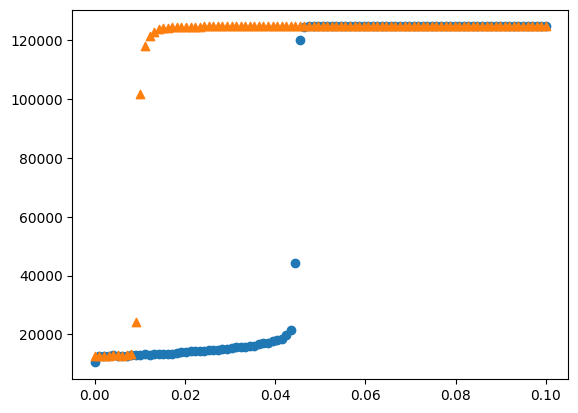

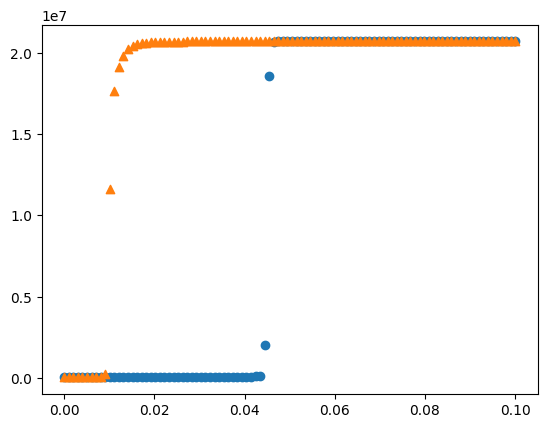

In [3]:
import time
n = 500
a=2.2
G = graphWithComplement(n)
m=0
t = 0
its = 500000
burn_in = 50000
up_edges = []
up_tris = []
down_edges = []
down_tris = []

#upsweep
b_vals = np.linspace(0, 0.1, 100)
for b in b_vals:
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -G.number_of_common_neighbors(i, j, m)
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = G.number_of_common_neighbors(i, j, m)
            delta_m = 1
            G.add_edge(i, j)
        
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, time = {elapsed:.2f} s")

    up_edges.append(total_edges / (its-burn_in))
    up_tris.append(total_tris / (its-burn_in))

#downsweep
for b in reversed(b_vals):
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    for _ in range(its):
        i, j = np.random.randint(0, n, 2)
        while(i==j):
            i, j = np.random.randint(0, n, 2)
        if G.has_edge(i, j):
            delta_t = -G.number_of_common_neighbors(i, j, m) 
            delta_m = -1
            G.remove_edge(i, j)
        else:
            delta_t = G.number_of_common_neighbors(i, j, m)
            delta_m = 1
            G.add_edge(i, j)
        
        dH = -(a * delta_m - b * delta_t)
        if np.log(np.random.uniform()) <= dH:
            m += delta_m
            t += delta_t
        else:
            # revert
            if delta_m == -1:
                G.add_edge(i, j)
            else:
                G.remove_edge(i, j)
        
        if _ >= burn_in:
            total_edges += m
            total_tris += t

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, time = {elapsed:.2f} s")

    down_edges.append(total_edges / (its-burn_in))
    down_tris.append(total_tris / (its-burn_in))

plt.figure()
plt.scatter(b_vals, up_edges, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_edges, label = 'downsweep', marker = '^')

plt.figure()
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^')

plt.show()


In [7]:
import time
import numpy as np
import networkx as nx

n = 500
a = 2.2
G = graphWithComplement(n)
m = 0
t = 0

max_its = 800000
check_interval = 50000
tol = 0.01  # relative convergence tolerance

up_edges = []
up_tris = []
down_edges = []
down_tris = []

b_vals = np.linspace(0, 0.1, 35)
prev_avg_edges = None
prev_avg_tris = None


#upsweep
for b in b_vals:
    start_time = time.time()
    total_edges = 0
    total_tris = 0

    converged = False
    iteration = 0

    while iteration < max_its and not converged:
        edges_sum = 0
        tris_sum = 0

        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j:
                i, j = np.random.randint(0, n, 2)
            if G.has_edge(i, j):
                delta_t = -G.number_of_common_neighbors(i, j, m)
                delta_m = -1
                G.remove_edge(i, j)
            else:
                delta_t = G.number_of_common_neighbors(i, j, m)
                delta_m = 1
                G.add_edge(i, j)

            dH = -(a * delta_m - b * delta_t)
            if np.log(np.random.uniform()) <= dH:
                m += delta_m
                t += delta_t
            else:
                # revert
                if delta_m == -1:
                    G.add_edge(i, j)
                else:
                    G.remove_edge(i, j)

            edges_sum += m
            tris_sum += t

        iteration += check_interval

        avg_edges = edges_sum / check_interval
        avg_tris = tris_sum / check_interval

        if prev_avg_edges is not None:
            rel_diff_edges = abs(avg_edges - prev_avg_edges) / abs(prev_avg_edges + 1e-9)
            rel_diff_tris = abs(avg_tris - prev_avg_tris) / abs(prev_avg_tris + 1e-9)
            if rel_diff_edges < tol and rel_diff_tris < tol:
                converged = True

        print( avg_edges, avg_tris)
        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, iters = {iteration}, time = {elapsed:.2f}s, converged = {converged}")

    up_edges.append(prev_avg_edges)
    up_tris.append(prev_avg_tris)

#downsweep
for b in reversed(b_vals):
    start_time = time.time()
    total_edges = 0
    total_tris = 0
    
    converged = False
    iteration = 0

    while iteration < max_its and not converged:
        edges_sum = 0
        tris_sum = 0

        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j:
                i, j = np.random.randint(0, n, 2)
            if G.has_edge(i, j):
                delta_t = -G.number_of_common_neighbors(i, j, m)
                delta_m = -1
                G.remove_edge(i, j)
            else:
                delta_t = G.number_of_common_neighbors(i, j, m)
                delta_m = 1
                G.add_edge(i, j)

            dH = -(a * delta_m - b * delta_t)
            if np.log(np.random.uniform()) <= dH:
                m += delta_m
                t += delta_t
            else:
                # revert
                if delta_m == -1:
                    G.add_edge(i, j)
                else:
                    G.remove_edge(i, j)

            edges_sum += m
            tris_sum += t

        iteration += check_interval

        avg_edges = edges_sum / check_interval
        avg_tris = tris_sum / check_interval

        if prev_avg_edges is not None:
            rel_diff_edges = abs(avg_edges - prev_avg_edges) / abs(prev_avg_edges + 1e-9)
            rel_diff_tris = abs(avg_tris - prev_avg_tris) / abs(prev_avg_tris + 1e-9)
            if rel_diff_edges < tol and rel_diff_tris < tol:
                converged = True

        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris

    elapsed = time.time() - start_time
    print(f"b = {b:.4f}, iters = {iteration}, time = {elapsed:.2f}s, converged = {converged}")

    down_edges.append(prev_avg_edges)
    down_tris.append(prev_avg_tris)


2428.75232 282.43258
6045.51894 2513.9198
8382.22902 6299.3043
9832.45004 10062.88642
10791.95164 13425.0383
11450.71806 15937.8979
11849.51022 17851.17088
12038.49856 18841.0828
12139.96108 19300.24072
12096.03888 19061.33982
12185.3104 19282.1121
12161.12818 19201.2882
b = 0.0000, iters = 600000, time = 16.85s, converged = True
12256.8475 19789.79286
12265.03188 19803.05236
b = 0.0029, iters = 100000, time = 2.96s, converged = True
12487.6227 20830.19346
12583.51246 21306.13228
12705.34604 22261.51146
12723.19192 22320.53392
b = 0.0059, iters = 200000, time = 2.71s, converged = True
12671.42478 22013.01002
12934.65942 23392.11776
12948.27306 23429.58774
b = 0.0088, iters = 150000, time = 4.70s, converged = True
13033.1962 24068.7814
13118.47436 24351.82302
13119.6147 24142.53348
b = 0.0118, iters = 150000, time = 4.56s, converged = True
13275.6707 24987.1405
13330.58256 25708.34982
13313.98856 25626.35166
b = 0.0147, iters = 150000, time = 4.59s, converged = True
13355.1868 25753.729

In [8]:
import matplotlib.pyplot as plt
up_edges = np.array(up_edges)
up_edges = up_edges / (n*(n-1)/2)
down_edges = np.array(down_edges)
down_edges = down_edges / (n*(n-1)/2)
up_tris = np.array(up_tris)
up_tris = up_tris / (n*(n-1)*(n-2)/6)
down_tris = np.array(down_tris)
down_tris = down_tris / (n*(n-1)*(n-2)/6)

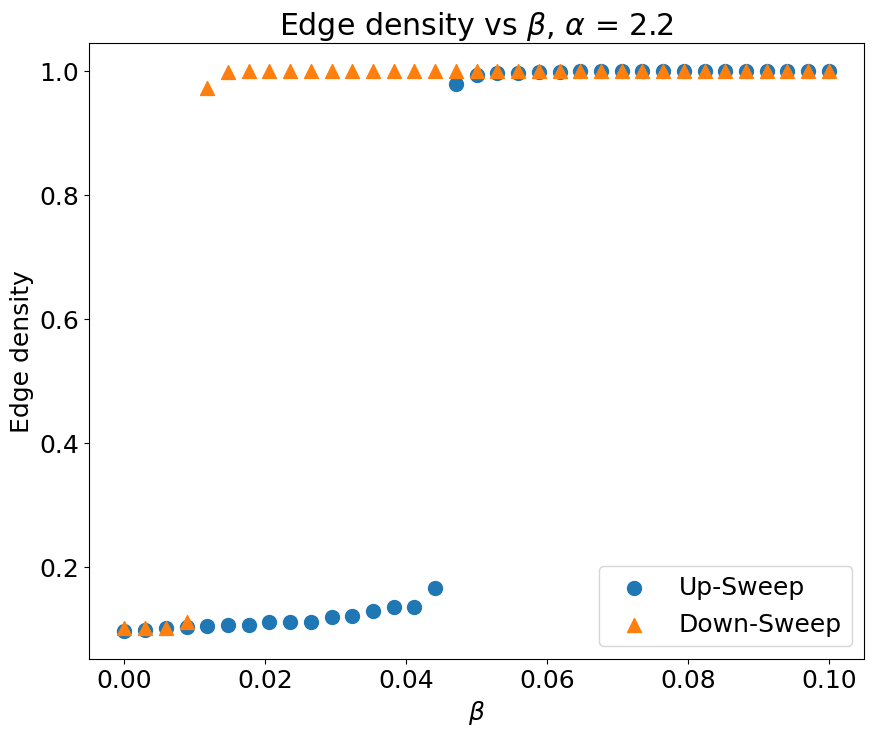

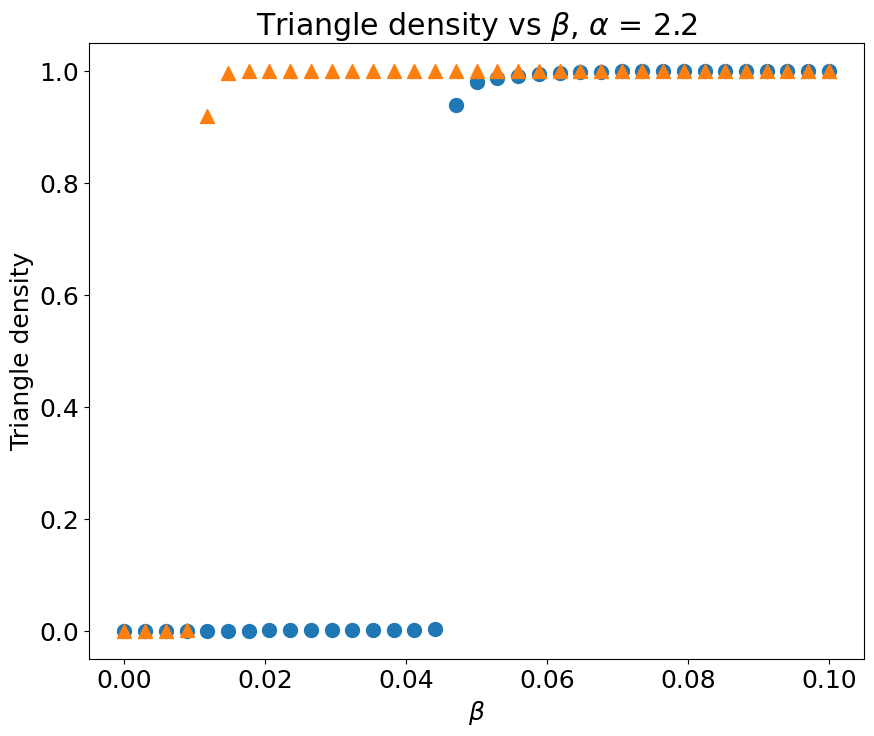

In [10]:
import matplotlib
matplotlib.rcParams.update({'font.size':18})
plt.figure(figsize=(10, 8))
plt.scatter(b_vals, up_edges, label='Up-Sweep', marker = 'o', s=100)
plt.scatter(b_vals[::-1], down_edges, label = 'Down-Sweep', marker = '^', s=100)
plt.title(r'Edge density vs $\beta$, $\alpha$ = 2.2')
plt.xlabel(r'$\beta$')
plt.ylabel('Edge density')
plt.legend(loc='lower right')

plt.figure(figsize=(10, 8))
plt.scatter(b_vals, up_tris, label='upsweep', marker = 'o', s=100)
plt.title(r'Triangle density vs $\beta$, $\alpha$ = 2.2')
plt.xlabel(r'$\beta$')
plt.ylabel('Triangle density')
plt.scatter(b_vals[::-1], down_tris, label = 'downsweep', marker = '^', s=100)

In [4]:
import time

n = 500

max_its = 1000000
check_interval = 50000
tol = 0.01  # relative convergence tolerance

a_vals = np.linspace(0.5, 3, 50)
b_vals = np.linspace(0, 0.05, 50)

up_tri_results = []
down_tri_results = []

up_edge_results = []
down_edge_results = []

for a in a_vals:
    prev_avg_edges = None
    prev_avg_tris = None
    start_time = time.time()
    G = graphWithComplement(n)
    m = 0
    t = 0
    up_edges = []
    up_tris = []
    down_edges = []
    down_tris = []
    #upsweep
    for b in b_vals:
        total_edges = 0
        total_tris = 0

        converged = False
        iteration = 0

        while iteration < max_its and not converged:
            edges_sum = 0
            tris_sum = 0

            for _ in range(check_interval):
                i, j = np.random.randint(0, n, 2)
                while i == j:
                    i, j = np.random.randint(0, n, 2)
                if G.has_edge(i, j):
                    delta_t = -G.number_of_common_neighbors(i, j, m)
                    delta_m = -1
                    G.remove_edge(i, j)
                else:
                    delta_t = G.number_of_common_neighbors(i, j, m)
                    delta_m = 1
                    G.add_edge(i, j)

                dH = -(a * delta_m - b * delta_t)
                if np.log(np.random.uniform()) <= dH:
                    m += delta_m
                    t += delta_t
                else:
                    # revert
                    if delta_m == -1:
                        G.add_edge(i, j)
                    else:
                        G.remove_edge(i, j)

                edges_sum += m
                tris_sum += t

            iteration += check_interval

            avg_edges = edges_sum / check_interval
            avg_tris = tris_sum / check_interval

            if prev_avg_edges is not None:
                rel_diff_edges = abs(avg_edges - prev_avg_edges) / abs(prev_avg_edges + 1e-9)
                rel_diff_tris = abs(avg_tris - prev_avg_tris) / abs(prev_avg_tris + 1e-9)
                if rel_diff_edges < tol and rel_diff_tris < tol:
                    print(b,_)
                    converged = True

            prev_avg_edges = avg_edges
            prev_avg_tris = avg_tris

        print(prev_avg_edges, prev_avg_tris)
        up_edges.append(prev_avg_edges)
        up_tris.append(prev_avg_tris)
        print(f"a = {a:.4f}, b = {b:.4f}, iters = {iteration}")

    #downsweep
    for b in reversed(b_vals):
        total_edges = 0
        total_tris = 0
        
        converged = False
        iteration = 0

        while iteration < max_its and not converged:
            edges_sum = 0
            tris_sum = 0

            for _ in range(check_interval):
                i, j = np.random.randint(0, n, 2)
                while i == j:
                    i, j = np.random.randint(0, n, 2)
                if G.has_edge(i, j):
                    delta_t = -G.number_of_common_neighbors(i, j, m)
                    delta_m = -1
                    G.remove_edge(i, j)
                else:
                    delta_t = G.number_of_common_neighbors(i, j, m)
                    delta_m = 1
                    G.add_edge(i, j)

                dH = -(a * delta_m - b * delta_t)
                if np.log(np.random.uniform()) <= dH:
                    m += delta_m
                    t += delta_t
                else:
                    # revert
                    if delta_m == -1:
                        G.add_edge(i, j)
                    else:
                        G.remove_edge(i, j)

                edges_sum += m
                tris_sum += t

            iteration += check_interval

            avg_edges = edges_sum / check_interval
            avg_tris = tris_sum / check_interval

            if prev_avg_edges is not None:
                rel_diff_edges = abs(avg_edges - prev_avg_edges) / abs(prev_avg_edges + 1e-9)
                rel_diff_tris = abs(avg_tris - prev_avg_tris) / abs(prev_avg_tris + 1e-9)
                if rel_diff_edges < tol and rel_diff_tris < tol:
                    converged = True

            prev_avg_edges = avg_edges
            prev_avg_tris = avg_tris

        down_edges.append(prev_avg_edges)
        down_tris.append(prev_avg_tris)
        print(f"a = {a:.4f}, b = {b:.4f}, iters = {iteration}")
    up_tri_results.append(up_tris)
    down_tri_results.append(down_tris)
    up_edge_results.append(up_edges)
    down_edge_results.append(down_edges)
    print(f"a = {a:.4f}, time = {time.time() - start_time:.2f}s")



KeyboardInterrupt: 

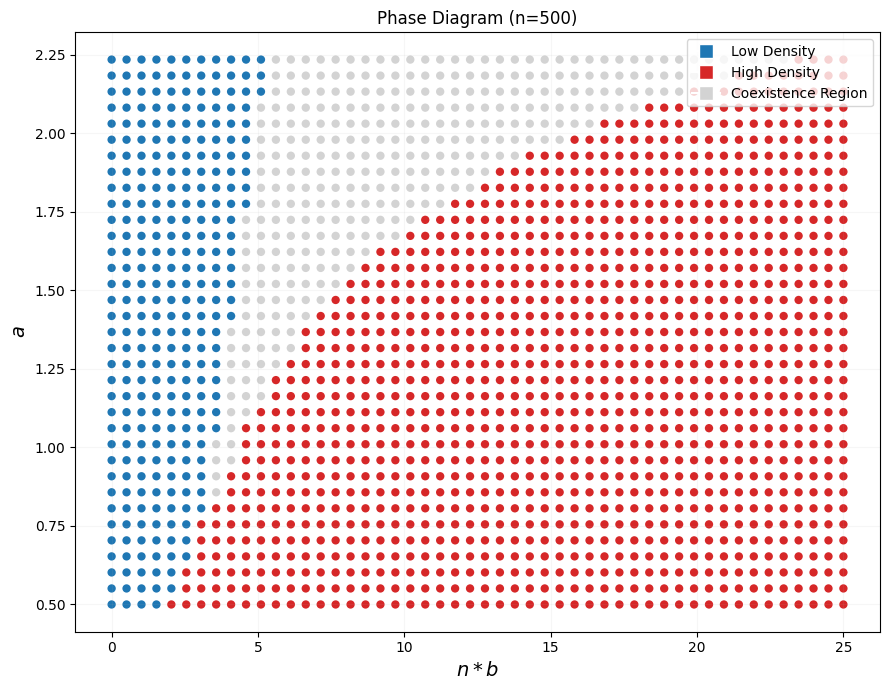

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Preparation & Parameters ---
n_nodes = n  # assuming 'n' variable from simulation is still available

# Convert results to 2D numpy arrays for easier math
E_up = np.array(up_edge_results)
# CRITICAL: Reverse the down results along axis 1 so they align with b_vals
E_down = np.array([row[::-1] for row in down_edge_results])

# Define Thresholds
max_possible_edges = n_nodes * (n_nodes - 1) / 2

# Hysteresis threshold: If difference between up and down is bigger than this%
# we call it coexistence. (Adjust 0.05 if needed, e.g., between 0.02 and 0.10)
hyst_threshold = 0.2 * max_possible_edges

# Density threshold: Midpoint to distinguish low from high when stable
density_threshold = 0.5 * max_possible_edges


# Lists to store coordinates and colors for plotting
plot_x = []
plot_y = []
plot_colors = []

# --- 2. Classification Loop ---
# Iterate through every simulated point
for i in range(len(a_vals)-15):
    for j in range(len(b_vals)):
        
        # Get coordinates for the plot
        # X-axis is n * alpha (which is n * b)
        x_coord = b_vals[j]*n
        # Y-axis is theta (which is a)
        y_coord = a_vals[i]
        
        # Get edge counts
        e_u = E_up[i, j]
        e_d = E_down[i, j]
        
        # Calculate difference (hysteresis magnitude)
        diff = e_d - e_u
        avg_e = (e_u + e_d) / 2.0

        # Determine Color based on region definition
        if diff > hyst_threshold:
            # Coexistence: Significant difference between up and down sweeps
            c = 'lightgray' 
        elif avg_e < density_threshold:
            # Stable Low Density: No significant diff, low edge count
            c = 'tab:blue'
        else:
            # Stable High Density: No significant diff, high edge count
            c = 'tab:red'
            
        plot_x.append(x_coord)
        plot_y.append(y_coord)
        plot_colors.append(c)


# --- 3. Plotting ---
plt.figure(figsize=(9, 7))

# Scatter plot with defined colors
# s=50 controls point size, marker='s' uses squares which pack nicely
plt.scatter(plot_x, plot_y, c=plot_colors, edgecolors='none')

# Formatting to match the reference image style
plt.xlabel(r'$n*b$', fontsize=14)
plt.ylabel(r'$a$', fontsize=14)
plt.title(f"Phase Diagram (n={n_nodes})")

# Create a custom legend (since scatter handles individual points)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Low Density',
           markerfacecolor='tab:blue', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='High Density',
           markerfacecolor='tab:red', markersize=10),
    Line2D([0], [0], marker='s', color='w', label='Coexistence Region',
           markerfacecolor='lightgray', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right')

plt.grid(True, which="both", ls="-", alpha=0.1)
plt.tight_layout()
plt.show()

In [20]:
def run_chain(G, m, t, n):
    max_its = 1000000
    check_interval = 50000
    tol = 0.01  # relative convergence tolerance
    converged = False
    iteration = 0
    prev_avg_edges = None
    prev_avg_tris = None

    while iteration < max_its and not converged:
        edges_sum = 0
        tris_sum = 0

        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j:
                i, j = np.random.randint(0, n, 2)

            if G.has_edge(i, j):
                delta_t = -G.number_of_common_neighbors(i, j, m)
                delta_m = -1
                G.remove_edge(i, j)
            else:
                delta_t = G.number_of_common_neighbors(i, j, m)
                delta_m = 1
                G.add_edge(i, j)

            dH = -(a * delta_m - b * delta_t)
            if np.log(np.random.uniform()) <= dH:
                m += delta_m
                t += delta_t
            else:
                if delta_m == -1:
                    G.add_edge(i, j)
                else:
                    G.remove_edge(i, j)

            edges_sum += m
            tris_sum += t

        iteration += check_interval

        avg_edges = edges_sum / check_interval
        avg_tris = tris_sum / check_interval

        if prev_avg_edges is not None:
            if (abs(avg_edges - prev_avg_edges) / (abs(prev_avg_edges) + 1e-9) < tol and
                abs(avg_tris - prev_avg_tris) / (abs(prev_avg_tris) + 1e-9) < tol):
                converged = True

        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris

    return m, t


In [ ]:
#doing as above but instead of using the previous as a starting point, start 2 each from full and empty graphs and check they converge to the same point
import time
n = 500

a_vals = np.linspace(0.5, 3, 20)
b_vals = np.linspace(0, 0.05, 20)

max_edges = n*(n-1)//2
max_tris = n*(n-1)*(n-2)//6

empty_edge_results = []
full_edge_results = []
empty_tri_results = []
full_tri_results = []

for a in a_vals:
    for b in b_vals:
        start_time = time.time()
        G_empty, m_empty, t_empty = graphWithComplement(n, empty=True), 0, 0
        G_full, m_full, t_full = graphWithComplement(n, empty=False), n*(n-1)//2, n*(n-1)*(n-2)//6

        m_empty, t_empty = run_chain(G_empty, m_empty, t_empty, n)
        m_full, t_full = run_chain(G_full, m_full, t_full, n)

        elapsed = time.time() - start_time
        print(f"a = {a:.4f}, b = {b:.4f}, time = {elapsed:.2f}s")
        empty_edge_results.append(m_empty/max_edges)
        full_edge_results.append(m_full/max_edges)
        empty_tri_results.append(t_empty/max_tris)
        full_tri_results.append(t_full/max_tris)
        print(m_empty, m_full, t_empty, t_full)

a = 0.5000, b = 0.0000, time = 46.89s
46917 47524 1102835 1145062
a = 0.5000, b = 0.0026, time = 66.15s
54276 55146 1709100 1793906
a = 0.5000, b = 0.0053, time = 145.52s
78210 82821 5115551 6071989
a = 0.5000, b = 0.0079, time = 54.95s
118452 120233 17728961 18540408
a = 0.5000, b = 0.0105, time = 36.00s
123023 124097 19860265 20384951
a = 0.5000, b = 0.0132, time = 30.30s
123989 124566 20331816 20616998
a = 0.5000, b = 0.0158, time = 27.53s
124155 124702 20413547 20684603
a = 0.5000, b = 0.0184, time = 26.22s
123999 124742 20336798 20704516
a = 0.5000, b = 0.0211, time = 24.86s
124120 124745 20396346 20706010
a = 0.5000, b = 0.0237, time = 25.00s
124118 124748 20395450 20707504
a = 0.5000, b = 0.0263, time = 24.94s
124129 124750 20400778 20708500
a = 0.5000, b = 0.0289, time = 24.60s
124186 124750 20428860 20708500
a = 0.5000, b = 0.0316, time = 26.34s
124201 124750 20436290 20708500
a = 0.5000, b = 0.0342, time = 39.77s
124176 124750 20423934 20708500
a = 0.5000, b = 0.0368, time = 

In [1]:
print(empty_edge_results)
print(full_edge_results)
print(empty_tri_results)
print(full_tri_results)

NameError: name 'empty_edge_results' is not defined

In [25]:
print(up_edge_results)
print(down_edge_results)
print(up_tri_results)
print(down_tri_results)

[[47100.64346, 49098.83148, 52643.19754, 56451.32412, 62036.54102, 74360.37934, 102069.9148, 114713.43676, 118949.27436, 121224.0174, 122554.46648, 122884.15952, 123257.43498, 123625.73912, 123911.65178, 124158.56726, 124319.3592, 124450.22542, 124536.3128, 124594.52266, 124643.02644, 124675.86468, 124701.20342, 124718.76778, 124730.06898, 124735.65974, 124742.45684, 124746.1542, 124747.99494, 124749.44256, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0, 124750.0], [45487.41204, 46941.26116, 50255.2873, 53764.46754, 59653.34184, 68999.72796, 96785.03726, 113721.46902, 118802.51222, 121137.03484, 122433.44912, 122796.47048, 123190.69468, 123541.12422, 123842.71782, 124094.16458, 124269.91556, 124404.1441, 124505.15066, 124570.73786, 124627.24352, 124664.98072, 124687.33244, 124700.00324, 124710.4342, 124721.87846, 124731.68934, 124739.9687, 124741

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # required for 3D plotting

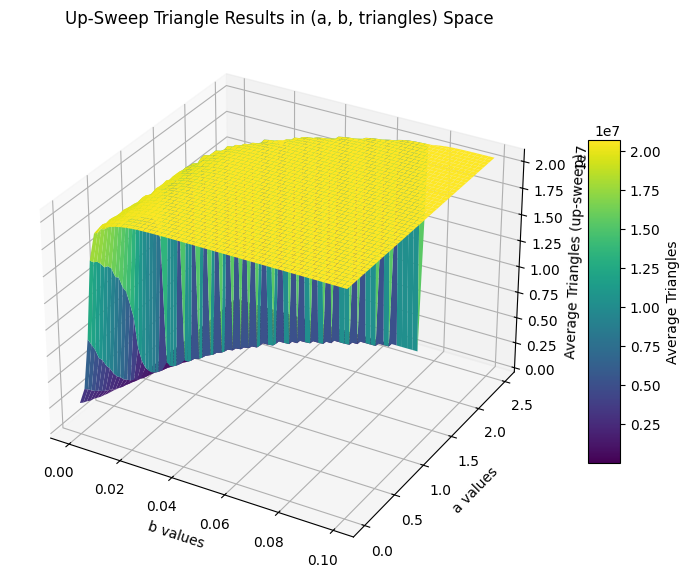

In [5]:
# Convert results list to array
np_up_tri_results = np.array(up_tri_results)  # shape: (len(a_vals), len(b_vals))

# Create meshgrid for a and b
A, B = np.meshgrid(b_vals, a_vals)  # note order (b_vals first) to match dimensions

# Plot the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(A, B, np_up_tri_results, cmap='viridis', edgecolor='none')

# Labels and title
ax.set_xlabel('b values')
ax.set_ylabel('a values')
ax.set_zlabel('Average Triangles (up-sweep)')
ax.set_title('Up-Sweep Triangle Results in (a, b, triangles) Space')

fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, label='Average Triangles')
plt.show()

In [6]:
%matplotlib widget


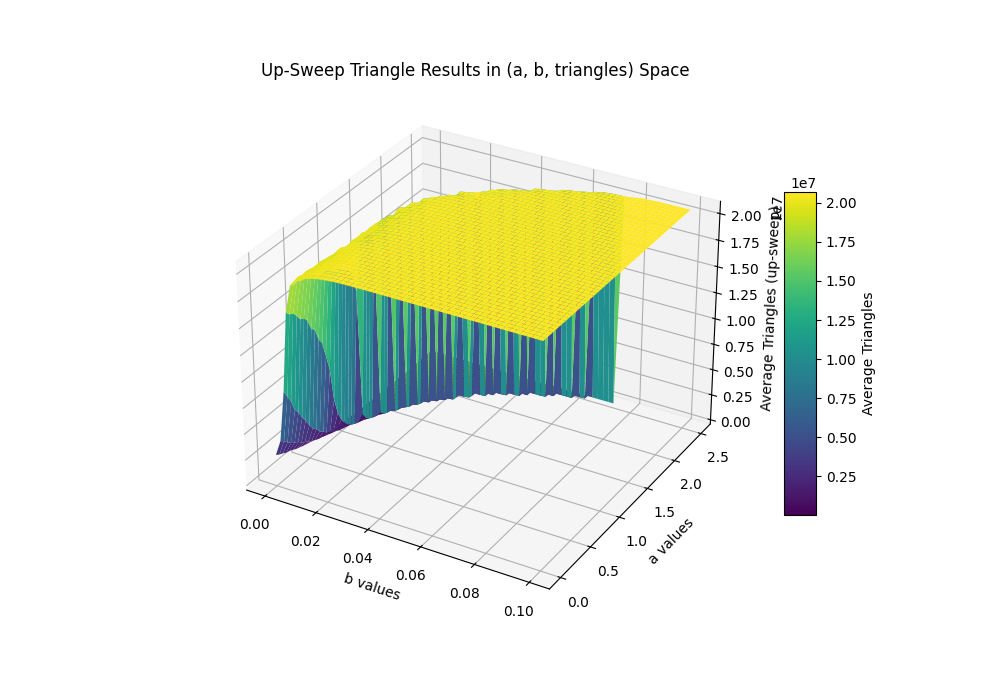

In [7]:
# Convert results list to array
np_up_tri_results = np.array(up_tri_results)  # shape: (len(a_vals), len(b_vals))

# Create meshgrid for a and b
A, B = np.meshgrid(b_vals, a_vals)  # note order (b_vals first) to match dimensions

# Plot the 3D surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(A, B, np_up_tri_results, cmap='viridis', edgecolor='none')

# Labels and title
ax.set_xlabel('b values')
ax.set_ylabel('a values')
ax.set_zlabel('Average Triangles (up-sweep)')
ax.set_title('Up-Sweep Triangle Results in (a, b, triangles) Space')

fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, label='Average Triangles')
plt.show()

In [2]:
empty_edge_results = [0.3760881763527054, 0.43507815631262525, 0.626933867735471, 0.9495150300601203, 0.9861563126252505, 0.9938997995991984, 0.9952304609218436, 0.9939799599198397, 0.9949498997995992, 0.994933867735471, 0.9950220440881764, 0.9954789579158316, 0.9955991983967936, 0.9953987975951903, 0.9956392785571142, 0.9957354709418837, 0.995687374749499, 0.995567134268537, 0.9958637274549098, 0.995815631262525, 0.3470941883767535, 0.389811623246493, 0.5059639278557114, 0.9274629258517034, 0.9840801603206413, 0.9921763527054108, 0.9954869739478958, 0.9958316633266533, 0.9960881763527054, 0.9964729458917836, 0.9946693386773547, 0.9949659318637275, 0.9953667334669338, 0.9953106212424849, 0.995687374749499, 0.9952945891783567, 0.9955350701402805, 0.9954068136272545, 0.9957595190380761, 0.9958236472945892, 0.31601603206412826, 0.35566332665330663, 0.42545090180360723, 0.8757995991983968, 0.9816352705410821, 0.9923046092184369, 0.9949739478957916, 0.9947815631262525, 0.9953907815631262, 0.9958476953907816, 0.9961523046092184, 0.9962404809619239, 0.9948537074148297, 0.9949018036072145, 0.9948617234468938, 0.9951743486973947, 0.9950701402805612, 0.9950701402805612, 0.9951743486973947, 0.9955430861723447, 0.2908697394789579, 0.3175310621242485, 0.3594228456913828, 0.6321763527054108, 0.9768817635270541, 0.9917915831663326, 0.9953587174348697, 0.9959038076152305, 0.9963206412825651, 0.9953907815631262, 0.9953907815631262, 0.9960400801603206, 0.996064128256513, 0.996248496993988, 0.9944609218436874, 0.99462124248497, 0.9948296593186373, 0.9950541082164329, 0.9950140280561123, 0.9950460921843688, 0.26273346693386773, 0.2839759519038076, 0.3132985971943888, 0.40077755511022045, 0.9506372745490982, 0.9919438877755511, 0.9944929859719439, 0.995503006012024, 0.995567134268537, 0.9962565130260521, 0.9968176352705411, 0.9950861723446893, 0.9953587174348697, 0.9958316633266533, 0.9959438877755511, 0.9959038076152305, 0.9941563126252505, 0.9960080160320641, 0.9965290581162325, 0.9962965931863728, 0.23700200400801602, 0.2508937875751503, 0.27763527054108217, 0.31600801603206413, 0.5908216432865732, 0.9835751503006012, 0.9937795591182365, 0.9954789579158316, 0.9954308617234469, 0.9949819639278558, 0.9955991983967936, 0.9961603206412826, 0.9962645290581162, 0.9949819639278558, 0.9950541082164329, 0.9954468937875751, 0.9958797595190381, 0.9956553106212425, 0.9956392785571142, 0.995687374749499, 0.2168817635270541, 0.22581162324649298, 0.24002404809619238, 0.2659559118236473, 0.3051142284569138, 0.8926092184368738, 0.98887374749499, 0.9944609218436874, 0.9950781563126253, 0.9948937875751503, 0.9954308617234469, 0.9963206412825651, 0.9951182364729458, 0.9954468937875751, 0.9963286573146293, 0.9961603206412826, 0.9946292585170341, 0.99462124248497, 0.9951102204408817, 0.9953667334669338, 0.192, 0.20029659318637275, 0.2121683366733467, 0.22793587174348698, 0.2510861723446894, 0.2992064128256513, 0.9043206412825652, 0.9894188376753507, 0.9956072144288577, 0.995623246492986, 0.9954709418837675, 0.994869739478958, 0.9956953907815631, 0.9960561122244489, 0.9947014028056113, 0.9949819639278558, 0.9958877755511022, 0.9959038076152305, 0.9959278557114228, 0.9960881763527054, 0.17282565130260522, 0.18112224448897796, 0.1872064128256513, 0.19389178356713427, 0.20793587174348696, 0.23029258517034068, 0.2717434869739479, 0.8151342685370742, 0.9828376753507014, 0.992745490981964, 0.9959919839679359, 0.9956312625250501, 0.9954549098196392, 0.9960240480961924, 0.9947815631262525, 0.9958877755511022, 0.9961603206412826, 0.9946052104208417, 0.99462124248497, 0.9950781563126253, 0.15531062124248496, 0.15522244488977957, 0.16409619238476955, 0.1677755511022044, 0.17854909819639278, 0.18909018036072145, 0.2004248496993988, 0.23203206412825653, 0.3513186372745491, 0.929995991983968, 0.9855551102204408, 0.9924248496993988, 0.9951743486973947, 0.9951823647294589, 0.9958236472945892, 0.9953346693386773, 0.9957595190380761, 0.9964248496993988, 0.9947575150300602, 0.9951342685370741, 0.1374428857715431, 0.1402244488977956, 0.14514629258517034, 0.1512064128256513, 0.1545250501002004, 0.15990380761523046, 0.16702204408817636, 0.18064128256513026, 0.18795991983967936, 0.22240480961923847, 0.3693547094188377, 0.9445450901803607, 0.9807535070140281, 0.9903567134268537, 0.993811623246493, 0.9955991983967936, 0.9949819639278558, 0.9956553106212425, 0.9965450901803607, 0.9951663326653306, 0.1229498997995992, 0.12471342685370741, 0.1287134268537074, 0.1318316633266533, 0.13923046092184369, 0.13787575150300602, 0.1417555110220441, 0.14605210420841683, 0.15656112224448898, 0.16247695390781564, 0.17246492985971945, 0.19649699398797596, 0.2583967935871743, 0.8715831663326653, 0.9636072144288577, 0.9821643286573146, 0.98887374749499, 0.9921202404809619, 0.9948376753507014, 0.9959038076152305, 0.1106693386773547, 0.1117995991983968, 0.11161523046092184, 0.11338677354709419, 0.11785170340681363, 0.12134669338677355, 0.12228456913827655, 0.12416833667334669, 0.12793587174348697, 0.13085370741482966, 0.13718637274549098, 0.14620440881763527, 0.1496432865731463, 0.1626372745490982, 0.18303006012024048, 0.3890420841683367, 0.8654909819639278, 0.9502685370741483, 0.9728577154308617, 0.985314629258517, 0.09910220440881763, 0.09858917835671342, 0.10061723446893787, 0.10266933867735471, 0.10179559118236473, 0.10508216432865732, 0.10415230460921844, 0.10791983967935871, 0.1068937875751503, 0.11294589178356713, 0.11539879759519038, 0.1201122244488978, 0.12084168336673347, 0.12280561122244489, 0.13057314629258518, 0.13854108216432864, 0.14735070140280562, 0.16139478957915832, 0.1794949899799599, 0.6497635270541082, 0.08840881763527055, 0.08577955911823647, 0.08959519038076152, 0.08924248496993988, 0.08847294589178356, 0.09107014028056112, 0.09232064128256513, 0.09261723446893788, 0.09436472945891784, 0.09775551102204409, 0.0953507014028056, 0.09916633266533066, 0.10370340681362726, 0.10476953907815631, 0.10161122244488978, 0.10797595190380761, 0.11034869739478959, 0.10926653306613227, 0.11715430861723447, 0.12455310621242485, 0.07742685370741482, 0.07628857715430862, 0.07740280561122244, 0.07996793587174349, 0.0794629258517034, 0.08068937875751503, 0.07915831663326653, 0.07947895791583166, 0.08254909819639279, 0.08310220440881763, 0.08313426853707415, 0.08526653306613226, 0.08551503006012023, 0.08779959919839679, 0.08800801603206412, 0.08782364729458918, 0.08807214428857715, 0.09171142284569138, 0.09519839679358717, 0.09623246492985972, 0.06777555110220441, 0.06710220440881763, 0.07038076152304609, 0.06928256513026051, 0.07022845691382766, 0.06933066132264529, 0.06887374749498998, 0.07155911823647294, 0.07198396793587174, 0.07217635270541083, 0.07338677354709419, 0.0743246492985972, 0.07289779559118237, 0.07365130260521043, 0.0762004008016032, 0.07700200400801603, 0.07724248496993988, 0.07525450901803607, 0.0785811623246493, 0.07890180360721442, 0.06041683366733467, 0.06006412825651303, 0.06145891783567134, 0.06064929859719439, 0.06274148296593186, 0.06174749498997996, 0.06286973947895791, 0.06288577154308617, 0.06276553106212425, 0.06364729458917835, 0.06317434869739479, 0.062420841683366736, 0.06440881763527054, 0.06530661322645291, 0.06634068136272545, 0.06419238476953908, 0.06792785571142285, 0.06697394789579159, 0.06553907815631263, 0.06501803607214429, 0.05462925851703407, 0.05386773547094188, 0.053122244488977954, 0.05350701402805611, 0.053715430861723444, 0.05497394789579158, 0.054220440881763525, 0.05438076152304609, 0.054653306613226454, 0.05543887775551102, 0.05397194388777555, 0.0538997995991984, 0.05490180360721443, 0.05694589178356713, 0.0527374749498998, 0.05539879759519038, 0.055302605210420845, 0.05834869739478958, 0.05567935871743487, 0.05907815631262525, 0.04747895791583166, 0.04723046092184369, 0.047663326653306616, 0.04765531062124249, 0.04801603206412826, 0.04712625250501002, 0.04928256513026052, 0.04647695390781563, 0.048, 0.04860120240480962, 0.04823246492985972, 0.04791983967935872, 0.04977154308617234, 0.04920240480961924, 0.04925851703406814, 0.04860921843687375, 0.04948296593186373, 0.0498436873747495, 0.04956312625250501, 0.04850501002004008]

full_edge_results = [0.38095390781563127, 0.44205210420841684, 0.6638957915831664, 0.9637915831663326, 0.9947655310621243, 0.9985250501002004, 0.9996152304609218, 0.999935871743487, 0.9999599198396794, 0.9999839679358717, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.3488176352705411, 0.3943887775551102, 0.5404969939879759, 0.9561843687374749, 0.9941563126252505, 0.9982925851703407, 0.9995991983967936, 0.9998957915831663, 0.9999679358717435, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.317875751503006, 0.35503006012024046, 0.4373306613226453, 0.9429659318637275, 0.9936673346693387, 0.9983166332665331, 0.9994228456913827, 0.9998476953907816, 0.9999519038076152, 0.9999919839679359, 1.0, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.29119038076152304, 0.3220921843687375, 0.37044488977955914, 0.9295951903807615, 0.9900280561122244, 0.9981963927855712, 0.9994308617234469, 0.9998957915831663, 0.9999759519038076, 0.9999679358717435, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.2656192384769539, 0.28513026052104207, 0.3229498997995992, 0.9064689378757516, 0.988993987975952, 0.9979478957915832, 0.999438877755511, 0.9998717434869739, 0.9999519038076152, 0.9999679358717435, 0.9999919839679359, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.2390060120240481, 0.253627254509018, 0.2818036072144289, 0.8424609218436874, 0.9848817635270541, 0.9975230460921843, 0.999254509018036, 0.9998076152304609, 0.9999679358717435, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.2173947895791583, 0.22864929859719438, 0.24239679358717434, 0.6401042084168337, 0.9822364729458918, 0.996809619238477, 0.9993907815631262, 0.9998076152304609, 0.9999438877755511, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.19628056112224448, 0.2036072144288577, 0.217875751503006, 0.26650901803607213, 0.9771943887775552, 0.9963687374749499, 0.9991743486973947, 0.9996953907815631, 0.9999198396793587, 0.9999839679358717, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.17672945891783567, 0.18265330661322646, 0.18946693386773547, 0.20775951903807616, 0.9743086172344689, 0.9959198396793587, 0.9990460921843687, 0.9997034068136272, 0.9999519038076152, 0.9999519038076152, 0.9999839679358717, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.1573627254509018, 0.16378356713426853, 0.16707815631262524, 0.17722645290581163, 0.963374749498998, 0.9956713426853707, 0.9990701402805611, 0.9997194388777555, 0.9999118236472946, 0.9999679358717435, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.1419559118236473, 0.14154709418837674, 0.14755911823647294, 0.15111022044088177, 0.9579078156312625, 0.9948537074148297, 0.9986773547094189, 0.999503006012024, 0.9998637274549098, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 1.0, 0.12847294589178357, 0.12948296593186373, 0.1318316633266533, 0.13399599198396794, 0.9446332665330661, 0.9940440881763527, 0.9986052104208417, 0.9995991983967936, 0.9999118236472946, 0.9999519038076152, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.11238476953907815, 0.11398797595190381, 0.1177875751503006, 0.11797995991983969, 0.9162645290581163, 0.9933386773547094, 0.9981082164328657, 0.9996392785571142, 0.999935871743487, 0.9999679358717435, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.09777955911823648, 0.10282164328657314, 0.10217234468937876, 0.10412825651302605, 0.7606092184368738, 0.9898597194388777, 0.9981082164328657, 0.9994709418837675, 0.9998957915831663, 0.9999519038076152, 0.9999919839679359, 1.0, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.08687775551102205, 0.08933867735470942, 0.08997194388777555, 0.09173547094188376, 0.14528256513026053, 0.988745490981964, 0.997498997995992, 0.9993106212424849, 0.9998316633266533, 0.9999278557114228, 0.9999839679358717, 0.9999919839679359, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0772745490981964, 0.0780681362725451, 0.08143486973947896, 0.07996793587174349, 0.09022044088176352, 0.9846733466933868, 0.9973466933867735, 0.9992865731462925, 0.9997595190380761, 0.9999599198396794, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.07104609218436873, 0.06852905811623246, 0.06983567134268537, 0.07212825651302605, 0.07424448897795591, 0.9812665330661323, 0.9973306613226453, 0.9990941883767535, 0.9998076152304609, 0.9999519038076152, 0.9999679358717435, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.06003206412825651, 0.06046492985971944, 0.06183567134268537, 0.06304609218436874, 0.06382364729458918, 0.9768336673346694, 0.9968016032064129, 0.9991823647294589, 0.9997194388777555, 0.999935871743487, 0.9999679358717435, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.05344288577154309, 0.05396392785571142, 0.05517434869739479, 0.05478156312625251, 0.05433266533066132, 0.9688416833667335, 0.9957915831663327, 0.9990781563126252, 0.9996953907815631, 0.9999038076152305, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.048032064128256516, 0.04896192384769539, 0.04854509018036072, 0.047887775551102206, 0.049891783567134265, 0.9602565130260521, 0.9954629258517034, 0.9987655310621243, 0.9996392785571142, 0.9999438877755511, 0.9999679358717435, 0.9999839679358717, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

empty_tri_results = [0.05325518506893305, 0.08253132771567231, 0.24702663157640584, 0.856119999034213, 0.9590392833860492, 0.9818101745659995, 0.9857569114131878, 0.9820507521066228, 0.9849262863075549, 0.9848830190501485, 0.9851403047057972, 0.9864963662264288, 0.9868551560953231, 0.9862584928893933, 0.9869755897336843, 0.987256537170727, 0.9871176087113988, 0.9867607504164957, 0.987642900258348, 0.9874972595793997, 0.0417917763237318, 0.059336359465919794, 0.12992389598474058, 0.7979331192505493, 0.9530065432068957, 0.9767101914672719, 0.9865221527392134, 0.9875451143250357, 0.988309727889514, 0.9894579520486757, 0.9840981239587608, 0.9849710022454548, 0.9861643286573146, 0.9859969577709636, 0.9871175604220489, 0.9859488615785789, 0.9866650892145737, 0.9862858729507207, 0.9873339932877804, 0.98752179056909, 0.03159060289253205, 0.045107757684042786, 0.07727836395682933, 0.6720283458483232, 0.9459210469131033, 0.9770977134992878, 0.9849983340174324, 0.9844232078615062, 0.986237535311587, 0.9875938865683174, 0.9885019677910037, 0.988765144747326, 0.9846407996716324, 0.9847818045730015, 0.9846606465943936, 0.9855929207813217, 0.985284689861651, 0.985284013810754, 0.9855937899896178, 0.9866883163918198, 0.024594200449090952, 0.03208233334138156, 0.04662993456793104, 0.2535177825530579, 0.932269068256996, 0.9755759229301978, 0.9861419706883647, 0.9877606296931212, 0.989003790713958, 0.986237100707439, 0.986235748605645, 0.9881675157544003, 0.9882356037375957, 0.9887885650819712, 0.9834765434483425, 0.9839534973561581, 0.9845659511794673, 0.9852379457710602, 0.9851152425332593, 0.98521119347128, 0.01815075935002535, 0.0229444913924234, 0.030929473404640608, 0.06481816645338871, 0.8591902841828235, 0.9760251587512374, 0.9835711422845691, 0.9865697660381003, 0.9867599294975493, 0.988812516599464, 0.9904828452084893, 0.9853305647439458, 0.9861436608156071, 0.987547239056426, 0.9878800975444866, 0.9877602916676727, 0.9825723736629887, 0.9880714199483304, 0.9896231016249366, 0.988930052876838, 0.013310717821184538, 0.01581823888741338, 0.02142120385349011, 0.03182722070647319, 0.2077257164932274, 0.9515351184296303, 0.9814553927131371, 0.9864975251708236, 0.9863538160658667, 0.9850222855349253, 0.9868564116184175, 0.9885264987806939, 0.9888361783808581, 0.9850190018591399, 0.9852342274911269, 0.9864017673902021, 0.9876902238211362, 0.9870231547432213, 0.9869759277591327, 0.9871193954173407, 0.010197261993867253, 0.011535746191177535, 0.013861361276770408, 0.01894188376753507, 0.02862805128328947, 0.7116201559745998, 0.9669900765386195, 0.9834752396358983, 0.9853099934809377, 0.9847584808170557, 0.9863541058019654, 0.9890052876838014, 0.9854254050269213, 0.9864017191008523, 0.9890253277639617, 0.9885263539126445, 0.983972523359973, 0.9839530144626603, 0.9854015983774779, 0.9861605137986817, 0.007047878890310742, 0.008062389839920806, 0.009580848443875703, 0.01193408503754497, 0.01603066373711278, 0.02718994615737499, 0.7397988265688002, 0.9685846391578338, 0.9868791076128159, 0.9869301011661878, 0.9864759398314702, 0.9846857570562813, 0.9871402564164473, 0.9882162397083323, 0.9841846584735736, 0.9850222855349253, 0.9877165415167685, 0.9877633821860589, 0.9878306009609581, 0.9883123355144023, 0.005176425139435497, 0.005959243788782384, 0.006599367409517831, 0.00735958664316585, 0.009066180553878842, 0.012374821933022672, 0.020412439336504332, 0.5426638819808292, 0.9494052683680614, 0.9783961658256272, 0.9880248690151388, 0.9869518796629403, 0.9864248496993988, 0.988118888379168, 0.9844287611367313, 0.9877129198155347, 0.9885250501002004, 0.9839033730110824, 0.9839519038076152, 0.985307047830601, 0.003766810729893522, 0.0037323804234975977, 0.004418330637177971, 0.004743607697322356, 0.005741796846705459, 0.006851872419537871, 0.008168722988144965, 0.012773257358089674, 0.0452061230895526, 0.8044662336721636, 0.9572936716807108, 0.9774553444237873, 0.9855933553854698, 0.9856188038728059, 0.9875239635898303, 0.9860699229784871, 0.9873302267184972, 0.9893150155733154, 0.9843542506700147, 0.98547263201101, 0.002593089794045923, 0.002751865176135403, 0.0030571987348190356, 0.003469976096771857, 0.003719004273607456, 0.004153318685563899, 0.004728493130839994, 0.006011637733297921, 0.006768283555061931, 0.01130926914069102, 0.05310263901296569, 0.8427786174759156, 0.9433663471521356, 0.971354419682739, 0.9815513436511577, 0.9868540454402781, 0.985021464615979, 0.9870243136876162, 0.9896723084723664, 0.9855696936040756, 0.0018517516961634112, 0.001944032643600454, 0.0021444334452036602, 0.002311562884805756, 0.002722601830166357, 0.002631721273873047, 0.002883308786247193, 0.003184296303450274, 0.003921288359852235, 0.004379119685153439, 0.005299080087886617, 0.007841321196610088, 0.018190646352946857, 0.6625574039645556, 0.8947742714344351, 0.9474566965255813, 0.9669938913972523, 0.9765483255667963, 0.9845909650626554, 0.9877629958712606, 0.001348769828814255, 0.0014082623077480262, 0.001394596421759181, 0.0014686722843276915, 0.0016585460076780066, 0.001824854528333776, 0.0018633411401115484, 0.0019377067387787623, 0.0021243450756935557, 0.0022878045247120746, 0.002653354902576237, 0.003217471086751817, 0.0034657749233406574, 0.004515054204795132, 0.0063995460801120315, 0.06364797064007534, 0.6488031001762561, 0.8581763044160611, 0.9207924282299539, 0.9565996088562667, 0.0009703744839075741, 0.0009539078156312625, 0.001002535190863655, 0.0010884419441292224, 0.0010668566047758166, 0.0011672501629765555, 0.001143057198734819, 0.0012749354129946641, 0.0012491489002100587, 0.001472583721660188, 0.0015694038679769176, 0.0018020136658859888, 0.0018157761305744018, 0.0019109061496486949, 0.002314073930994519, 0.002779052080063742, 0.003365912547987541, 0.004460100924741048, 0.006210783011806746, 0.2775082695511505, 0.0006839220609894487, 0.0006228360335128087, 0.0007162759253446652, 0.0007222155153680856, 0.0006964772919332642, 0.0007613781780428327, 0.000796870850134003, 0.0008060458265929449, 0.0008591641113552406, 0.0009540043943308303, 0.0008892483762706136, 0.0009978994132844002, 0.0011474998189149382, 0.0011917328633169954, 0.0010984861288842746, 0.0013112972933819447, 0.001401212062679576, 0.0013642707100948886, 0.0016943767052176643, 0.002034478595745708, 0.0004633846005263539, 0.00044112321027597363, 0.0004696139266484777, 0.0005170823574860565, 0.0005104184272158776, 0.0005326798174662579, 0.0005025955525508849, 0.0005117222396600429, 0.000573339449984306, 0.0005853152087307145, 0.0006010092474104836, 0.0006423449308255064, 0.0006401236207354468, 0.0007029480648043074, 0.0007089359441775116, 0.0007030929328536591, 0.0007192215756814834, 0.0008023758360093681, 0.0009054735977980056, 0.0009379240408527899, 0.0003126735398507859, 0.00029895936451215685, 0.00036081802158533936, 0.00033083033536953423, 0.00034729700364584593, 0.0003424680686674554, 0.00033165125431586066, 0.0003736146992780742, 0.0003837071733829104, 0.0003891638699084917, 0.0004081415843735664, 0.00042687785208972163, 0.00040007726295965425, 0.00040659632518048145, 0.00046753748460776973, 0.0004745877296762199, 0.00047676075041649566, 0.00045276094357389477, 0.0005151990728444842, 0.0005172755148851921, 0.0002162397083323273, 0.00021314918994615737, 0.00023174058961296086, 0.000224545476495159, 0.00024366805900958544, 0.00023903228143033053, 0.00024381292705893715, 0.0002544365840113963, 0.0002542434266122607, 0.0002582514426443248, 0.0002607624888330879, 0.0002449718714537509, 0.00027080667358814014, 0.0002929231957891687, 0.0003052369799840645, 0.00026815075935002534, 0.00032334548615302897, 0.000320786150614482, 0.00029215056619262623, 0.0002847622956756887, 0.00016688799285317622, 0.00015587802110244585, 0.00014752396358983026, 0.00015013158847816113, 0.00015785788444358596, 0.00016582562715793033, 0.00015694038679769177, 0.00015751985899509864, 0.00016510128691117173, 0.00017471086751816886, 0.00015935485428688703, 0.00016056208803148466, 0.0001740831059709781, 0.0001918052973416713, 0.00015418789386000917, 0.00017326218702465172, 0.00017282758287659656, 0.00020991380351063573, 0.0001796846705459111, 0.00022024772436439143, 0.000110486032305575, 0.00010416012748388343, 0.00010628485887437525, 0.0001113069512519014, 0.00011396286549001618, 0.00010889248376270614, 0.00012057850641041119, 0.0001010213197479296, 0.00011333510394282541, 0.00011570128208223677, 0.00011338339329260932, 0.00011116208320254967, 0.00012791848757756478, 0.00012096482120868242, 0.00012318613129874207, 0.00011912982591689403, 0.00012574546683728904, 0.00012975348286935317, 0.00012787019822778085, 0.00011869522176883888]

full_tri_results = [0.05529429944225801, 0.08662655431344617, 0.2932124007050245, 0.8953042470483135, 0.9843760291667673, 0.9955814279160731, 0.998846029408214, 0.9998076152304609, 0.9998797595190381, 0.9999519038076152, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0424557548832605, 0.061458193495424585, 0.15837081391699062, 0.8742709515416375, 0.9825699591954994, 0.9948863027259338, 0.9987981263732284, 0.999687374749499, 0.9999038076152305, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.03210662288432286, 0.04485134123669025, 0.0840284907163725, 0.8385709249824951, 0.9811241277736196, 0.9949591713547578, 0.9982698408865924, 0.9995430861723447, 0.9998557114228457, 0.9999759519038076, 1.0, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.02470975686312384, 0.03350648284520849, 0.051028225124948694, 0.8034757225293961, 0.9703803752082478, 0.9945985947799213, 0.9982936958253857, 0.999687374749499, 0.9999278557114228, 0.9999038076152305, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.01872873457758891, 0.023233261704131154, 0.03383736146992781, 0.7450391385179999, 0.9673530192915952, 0.9938558080015453, 0.9983174058961296, 0.9996152304609218, 0.9998557114228457, 0.9999038076152305, 0.9999759519038076, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.01365535891059227, 0.01637269720163218, 0.022470579713644155, 0.5984854528333776, 0.9553323997392376, 0.9925886471738659, 0.9977651206026511, 0.9994228939807326, 0.9999038076152305, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.010272207064731873, 0.01197006060313398, 0.014300166598256754, 0.26381553468382546, 0.9476632300746071, 0.9904609701330371, 0.998173407055074, 0.9994229422700823, 0.9998316633266533, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.007556607190284182, 0.008454499360166115, 0.010374966801072024, 0.01904329140208127, 0.9331505420479513, 0.9891448921940266, 0.9975249776661758, 0.9990864620807881, 0.9997595190380761, 0.9999519038076152, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.005554675616292827, 0.006118888379167974, 0.006840910737136925, 0.009043967452978245, 0.924916435280199, 0.9878105608807978, 0.9971409807566941, 0.9991104618876306, 0.9998557114228457, 0.9998557114228457, 0.9999519038076152, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0038860854238597677, 0.004419296424173648, 0.004684839558635343, 0.0056407755269575295, 0.8941667914141536, 0.9870687398894173, 0.9972130767559215, 0.9991584615013159, 0.9997355192312336, 0.9999038076152305, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.002876306830528527, 0.0028435183620252554, 0.0032440785184827486, 0.0034479561532703962, 0.8790097785933313, 0.9846396890165874, 0.9960383417437284, 0.9985096940869691, 0.9995912306540793, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0021100031388077358, 0.002193978318081947, 0.0023277881063331484, 0.0024187169519762418, 0.842975638023034, 0.9822383562305333, 0.9958219088779969, 0.9987980297945288, 0.9997354709418838, 0.9998557114228457, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0014224593765844943, 0.0014755776613467899, 0.0016400994760605548, 0.001664920201849482, 0.7694873119733443, 0.9801502281671778, 0.9943349349301012, 0.9989181254074414, 0.9998076152304609, 0.9999038076152305, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0009461332303160538, 0.0010980998140860034, 0.0010832266943525605, 0.0011306951251901392, 0.44237313180578025, 0.9698964676340633, 0.9943350797981505, 0.9984137431489485, 0.999687374749499, 0.9998557114228457, 0.9999759519038076, 1.0, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.000658376994953763, 0.0007066180553878842, 0.000717386580389695, 0.0007874061375763576, 0.003103315063862665, 0.9666251539223024, 0.9925161648598402, 0.9979332641185986, 0.9994950382693097, 0.9997835671342685, 0.9999519038076152, 0.9999759519038076, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0004595214525436415, 0.0004810585025472632, 0.0005493396431417051, 0.0005147161793466451, 0.0007416761233309993, 0.9547353502185093, 0.9920627278653693, 0.99786145785547, 0.9992787502716276, 0.9998797595190381, 0.9999278557114228, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.00036270130622691166, 0.0003261945577902794, 0.00034184030712026465, 0.00038023034019846923, 0.0004134051235000121, 0.9448525967597846, 0.9920107202356521, 0.997284448414902, 0.9994228456913827, 0.9998557114228457, 0.9999038076152305, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0002141632662916194, 0.00022502836999299805, 0.00024289542941304296, 0.0002534707970157182, 0.00026052104208416834, 0.9321257454668372, 0.9904384672960379, 0.9975492672091171, 0.9991584615013159, 0.9998076152304609, 0.9999038076152305, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.00015317381751454718, 0.00015433276190936088, 0.00017104087693459207, 0.00016881956684453245, 0.0001580993311925055, 0.90943462829273, 0.9874280126518097, 0.9972371248521139, 0.9990863655020885, 0.9997114228456914, 0.9999278557114228, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0001113552406016853, 0.00011217615954801169, 0.00011439746963807132, 0.00011294878914455416, 0.00012400705024506845, 0.8854824347490161, 0.9864534852838207, 0.9963006977811044, 0.9989181254074414, 0.9998316633266533, 0.9999038076152305, 0.9999519038076152, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

In [8]:
def run_chain(G, m, t, n, a, b):
    max_its = 1000000
    check_interval = 50000
    tol = 0.01  # relative convergence tolerance
    converged = False
    prev_avg_edges = None
    prev_avg_tris = None
    
    converged = False
    total_iter = 0
    
    # Run in batches until converged or max_its reached
    while total_iter < max_its and not converged:
        
        batch_edges = 0
        batch_tris = 0
        
        # The MCMC Batch
        for _ in range(check_interval):
            i, j = np.random.randint(0, n, 2)
            while i == j:
                i, j = np.random.randint(0, n, 2)

            if G.has_edge(i, j):
                delta_t = -G.number_of_common_neighbors(i, j, m)
                delta_m = -1
                G.remove_edge(i, j)
            else:
                delta_t = G.number_of_common_neighbors(i, j, m)
                delta_m = 1
                G.add_edge(i, j)

            dH = -(a * delta_m - b * delta_t)
            if np.log(np.random.uniform()) <= dH:
                m += delta_m
                t += delta_t
            else:
                if delta_m == -1:
                    G.add_edge(i, j)
                else:
                    G.remove_edge(i, j)

            batch_edges += m
            batch_tris += t

        # -- Check Convergence --
        total_iter += check_interval
        avg_edges = batch_edges / check_interval
        avg_tris = batch_tris / check_interval
        
        # Calculate relative change
        if prev_avg_edges is not None: # Skip first check
            diff_e = abs(avg_edges - prev_avg_edges) / (prev_avg_edges + 1e-9)
            diff_t = abs(avg_tris - prev_avg_tris) / (prev_avg_tris + 1e-9)
            
            if diff_e < tol and diff_t < tol:
                converged = True
        
        prev_avg_edges = avg_edges
        prev_avg_tris = avg_tris

    return m, t


In [9]:
class graphWithComplement:

    def __init__(self, n, p=None):
        self.n = n
        self.half_of_all_edges = n*(n-1)//4
        if p is None:
            self.graph = nx.empty_graph(n)
            self.complement = nx.complete_graph(n)
        else:
            self.graph = nx.fast_gnp_random_graph(n, p)
            self.complement = nx.complement(self.graph)

    def add_edge(self, u, v):
        self.graph.add_edge(u, v)
        self.complement.remove_edge(u, v)

    def remove_edge(self, u, v):
        self.graph.remove_edge(u, v)
        self.complement.add_edge(u, v)

    def has_edge(self, u, v):
        return self.graph.has_edge(u, v)
    
    def number_of_common_neighbors(self, u, v, m=None):
        if m is None or m<self.half_of_all_edges:
            return len(nx.common_neighbors(self.graph, u, v))
        else:
            return self.n - 2 - len((self.complement.adj[u].keys() | self.complement.adj[v].keys()) - {u,v})

In [10]:
def run_simulation_step(a, b, n, max_edges, max_tris):
    # 1. Setup Graphs
    G_empty = graphWithComplement(n, p=0.1)
    m_empty = G_empty.graph.number_of_edges()
    t_empty = sum(nx.triangles(G_empty.graph).values()) // 3
    
    G_full = graphWithComplement(n, p=0.9)
    m_full = G_full.graph.number_of_edges()
    t_full = sum(nx.triangles(G_full.graph).values()) // 3

    # 2. Run Chain
    m_empty, t_empty = run_chain(G_empty, m_empty, t_empty, n, a, b,)
    m_full, t_full = run_chain(G_full, m_full, t_full, n, a, b)

    # 3. Calculate metrics
    res_empty_edge = m_empty / max_edges
    res_full_edge = m_full / max_edges
    res_empty_tri = t_empty / max_tris
    res_full_tri = t_full / max_tris
    
    # Return everything needed to reconstruct the results
    return (a, b, res_empty_edge, res_full_edge, res_empty_tri, res_full_tri)

In [14]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import itertools
import numpy as np
import networkx as nx

n=500
a_vals = np.linspace(0.5, 3, 20)
b_vals = np.linspace(0, 0.05, 20)
param_list = list(itertools.product(a_vals, b_vals))

print(f"Total simulations to run: {len(param_list)}")
print(n)
n=500
max_edges = n*(n-1)//2
max_tris = n*(n-1)*(n-2)//6
print(f"Max edges: {max_edges}, Max triangles: {max_tris}")
# 2. Run Parallel Jobs
# n_jobs=-1 uses all available CPU cores. 
# n_jobs=-2 uses all but one (keeps computer responsive).
results_flat = Parallel(n_jobs=-1)(
    delayed(run_simulation_step)(a, b, n, max_edges, max_tris) 
    for a, b in tqdm(param_list, desc="Running Simulations")
)

Total simulations to run: 400
500
Max edges: 124750, Max triangles: 20708500


Running Simulations:   0%|          | 0/400 [00:00<?, ?it/s]

In [19]:
import pandas as pd

# 1. Convert the flat results list directly into a DataFrame
df = pd.DataFrame(results_flat, columns=[
    'alpha', 'beta',
    'empty_edge', 'full_edge', 'empty_tri', 'full_tri'
])
df.to_pickle("simulation_results_repro.pkl")
# 2. View the first few rows (safeprint)
print(df.head())

   alpha      beta  empty_edge  full_edge  empty_tri  full_tri
0    0.5  0.000000    0.377355   0.382253   0.053728  0.055806
1    0.5  0.002632    0.434790   0.441218   0.082312  0.086049
2    0.5  0.005263    0.620473   0.659583   0.239431  0.287570
3    0.5  0.007895    0.948248   0.949347   0.852704  0.855667
4    0.5  0.010526    0.986100   0.985980   0.958880  0.958522


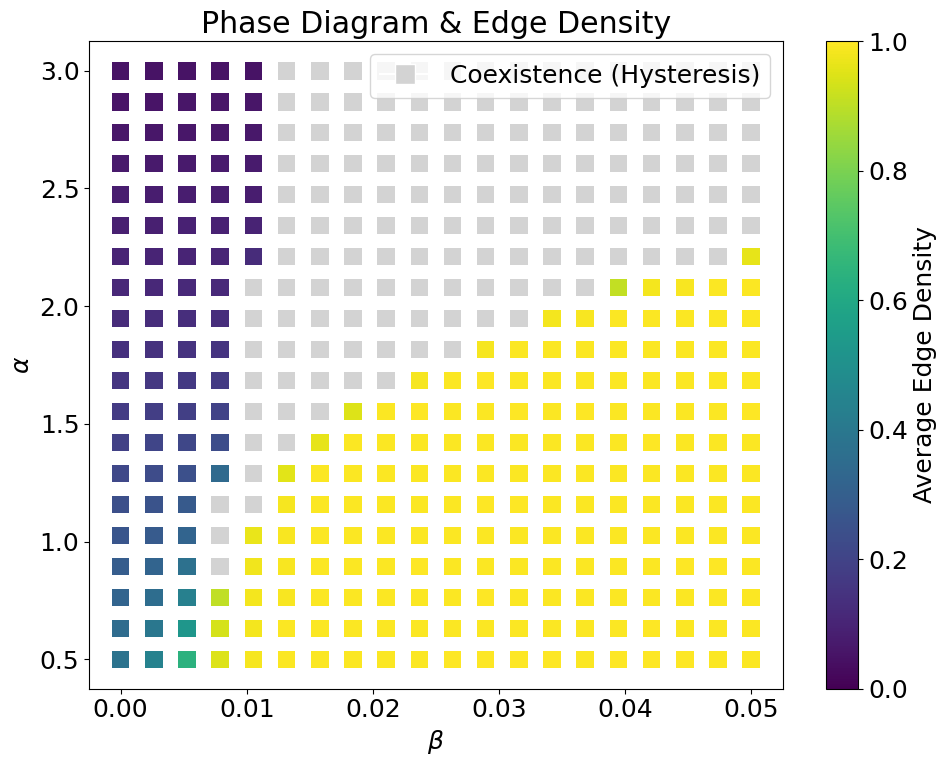

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import pandas as pd
import matplotlib
df = pd.read_pickle("simulation_results_repro.pkl")
# --- 1. Data Preparation ---
# Calculate metrics
df['diff'] = df['full_edge'] - df['empty_edge']
df['avg_density'] = (df['empty_edge'] + df['full_edge']) / 2.0

# Define Hysteresis Threshold
hyst_threshold = 0.2

# Split Data into two sets:
# 1. Hysteresis points (Coexistence)
hyst_mask = df['diff'] > hyst_threshold
hyst_df = df[hyst_mask]

# 2. Stable points (Low or High Density)
stable_df = df[~hyst_mask]


import matplotlib 
matplotlib.rcParams.update({'font.size': 18})


plt.figure(figsize=(10, 8))

# LAYER 1: The Density Heatmap (Stable points only)
# vmin=0, vmax=1 locks the color scale so 0 is always purple/blue and 1 is yellow
sc = plt.scatter(stable_df['beta'], stable_df['alpha'], 
                    c=stable_df['avg_density'], 
                    cmap='viridis', 
                    s=160, marker='s', edgecolors='none',
                    vmin=0, vmax=1)

# LAYER 2: The Hysteresis Overlay
# Plot these points in solid gray to "mask" the density
plt.scatter(hyst_df['beta'], hyst_df['alpha'], 
            c='lightgray', 
            s=160, marker='s', edgecolors='none')

# --- Formatting ---

# Colorbar (linked to the heatmap layer)
cbar = plt.colorbar(sc)
cbar.set_label('Average Edge Density')

# Custom Legend to explain the Gray region
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Coexistence (Hysteresis)',
            markerfacecolor='lightgray', markersize=15),
]
# We add the legend, but keep it simple so it doesn't block data
plt.legend(handles=legend_elements, loc='upper right', frameon=True)

plt.xlabel(r'$\beta$')
plt.ylabel(r'$\alpha$')
plt.title(f"Phase Diagram & Edge Density")

plt.tight_layout()
plt.show()